# Invoice Insights

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings

In [12]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline 

# Part 1: Business Requirements & Problem Definition

## 1. Core Business Problems
*   **Manual collections:** The AR team is chasing payments without a data-driven priority list.
*   **Cash Flow Unpredictability:** High variance in DSO (Days Sales Outstanding) makes liquidity planning difficult.
*   **Risk Blindness:** No distinction between accidental late payers and high-risk delinquents.

## 2. Key Success Metrics (KPIs)
*   **Average DSO:** Reduction from ~41 days to <25 days.
*   **Collection Effectiveness Index (CEI):** Targeting >90% of monthly billables.
*   **Bad Debt Ratio:** Keeping write-offs below 2% of total revenue.

## 3. Assumptions
*   Unpaid invoices are treated as "outstanding" based on the latest date in the dataset.
*   The primary currency is consistent across all transactions.
*   A "Bad Debt" is defined as any invoice >90 days past due that remains unpaid.

## 4. Analysis Approach
1.  **Cleaning:** Handle messy date formats and numeric inconsistencies in-memory.
2.  **Segmentation:** Apply RFM-style logic (Recency, Frequency, Monetary) using KMeans.
3.  **Strategy:** Map segments to automated vs. manual reminder workflows.
4.  **Forecasting:** Use historical realization rates to predict next 3 months of cash.

In [13]:
file_path = '../data/invoice_history.xlsx'
df = pd.read_excel(file_path).copy()

# 1. Clean Dates (Handle mixed formats/UTC)
for col in ['issue_date', 'due_date', 'paid_on_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)

# 2. Handle Messy Numeric Values
df['total_amount'] = pd.to_numeric(df['total_amount'], errors='coerce').fillna(0)
df = df[df['total_amount'] > 0] # Filter out noise/credit notes

# 3. Create Aging Features
snapshot_date = df['issue_date'].max() + pd.Timedelta(days=1)
df['effective_pay_date'] = df['paid_on_date'].fillna(snapshot_date)
df['days_to_settle'] = (df['effective_pay_date'] - df['due_date']).dt.days
df['is_paid'] = df['paid_on_date'].notna().astype(int)

print(f"Data cleaning complete. {len(df)} valid invoices analyzed.")


Data cleaning complete. 17692 valid invoices analyzed.


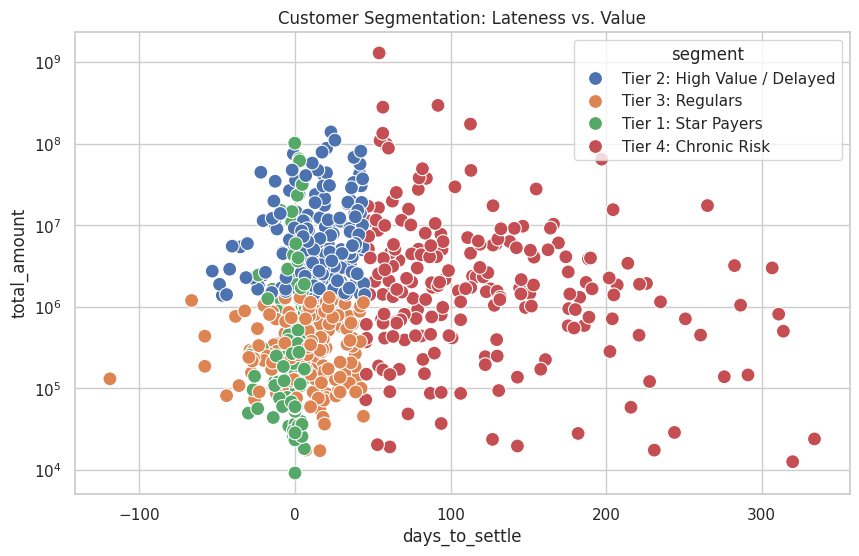

In [14]:
payer_stats = df.groupby('payer_id').agg({
    'total_amount': 'sum',
    'days_to_settle': 'mean',
    'is_paid': 'mean',
    'id': 'count'
}).rename(columns={'id': 'invoice_count', 'is_paid': 'reliability'})

# Scaling
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(payer_stats[['total_amount', 'days_to_settle', 'reliability']])

# Clustering
km = KMeans(n_clusters=4, random_state=42).fit(scaled_feat)
payer_stats['cluster'] = km.labels_

def segment_logic(row):
    if row['reliability'] > 0.9 and row['days_to_settle'] < 7: return "Tier 1: Star Payers"
    if row['days_to_settle'] > 45: return "Tier 4: Chronic Risk"
    if row['total_amount'] > payer_stats['total_amount'].median(): return "Tier 2: High Value / Delayed"
    return "Tier 3: Regulars"

payer_stats['segment'] = payer_stats.apply(segment_logic, axis=1)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=payer_stats, x='days_to_settle', y='total_amount', hue='segment', s=100)
plt.yscale('log')
plt.title('Customer Segmentation: Lateness vs. Value')
plt.show()


In [15]:
print("RECOMMENDED REMINDER SCHEDULES:")
strategies = {
    "Tier 1: Star Payers": "D-1 (Soft Email), D+7 (Friendly Check-in). Use SMS/WhatsApp for speed.",
    "Tier 2: High Value / Delayed": "D-5 (Confirmation), D+1 (Phone Call). Personalized account management.",
    "Tier 3: Regulars": "D-3 (Auto-remind), D+3 (Auto-remind), D+10 (Escalate).",
    "Tier 4: Chronic Risk": "Pre-payment required for future orders. Daily reminders starting D+1."
}

for seg, plan in strategies.items():
    avg_late = payer_stats[payer_stats['segment'] == seg]['days_to_settle'].mean()
    print(f"[{seg}] (Avg {avg_late:.1f} days late): {plan}")


RECOMMENDED REMINDER SCHEDULES:
[Tier 1: Star Payers] (Avg -2.0 days late): D-1 (Soft Email), D+7 (Friendly Check-in). Use SMS/WhatsApp for speed.
[Tier 2: High Value / Delayed] (Avg 13.9 days late): D-5 (Confirmation), D+1 (Phone Call). Personalized account management.
[Tier 3: Regulars] (Avg 8.0 days late): D-3 (Auto-remind), D+3 (Auto-remind), D+10 (Escalate).
[Tier 4: Chronic Risk] (Avg 118.2 days late): Pre-payment required for future orders. Daily reminders starting D+1.


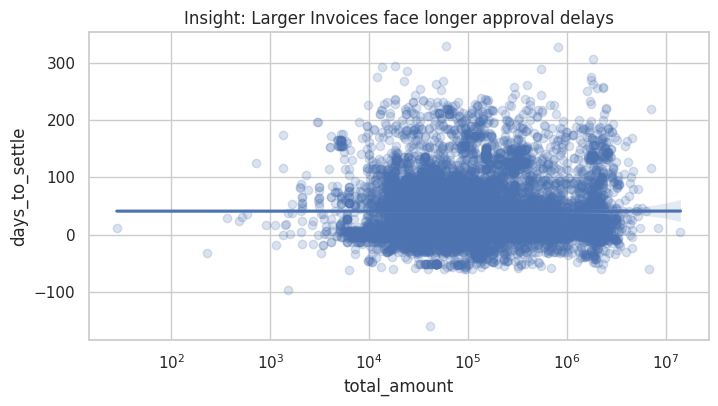

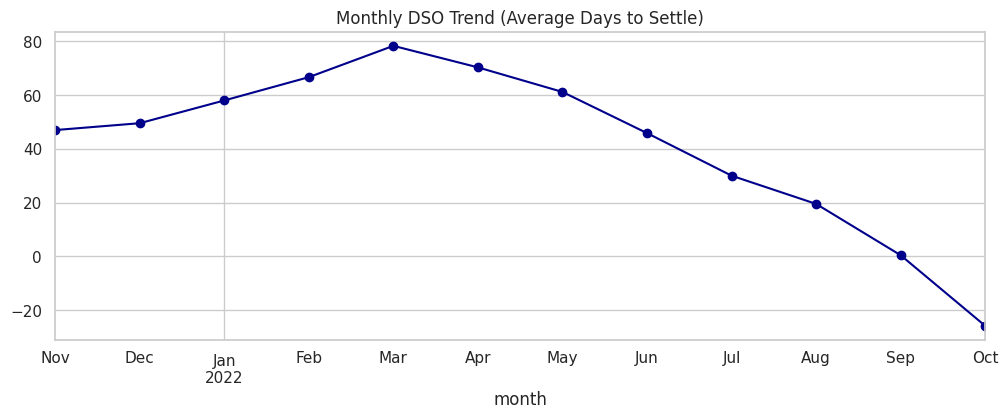

In [16]:

# Insight 1: Invoice Size vs. Delay
plt.figure(figsize=(8, 4))
sns.regplot(data=df[df['is_paid']==1], x='total_amount', y='days_to_settle', scatter_kws={'alpha':0.2})
plt.xscale('log')
plt.title('Insight: Larger Invoices face longer approval delays')
plt.show()

# DSO Trend
df['month'] = df['issue_date'].dt.to_period('M')
dso_trend = df.groupby('month')['days_to_settle'].mean()
plt.figure(figsize=(12, 4))
dso_trend.plot(kind='line', color='darkblue', marker='o')
plt.title('Monthly DSO Trend (Average Days to Settle)')
plt.show()


In [ ]:
###### CELL 7: Part 3E: Bad Debt Prediction

df['is_bad_debt'] = ((df['is_paid'] == 0) & (df['days_to_settle'] > 90)).astype(int)

# Use simple numeric features for classification
X = df[['total_amount', 'days_to_settle']]
y = df['is_bad_debt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)

print("BAD DEBT MODEL PERFORMANCE:")
print(classification_report(y_test, clf.predict(X_test)))


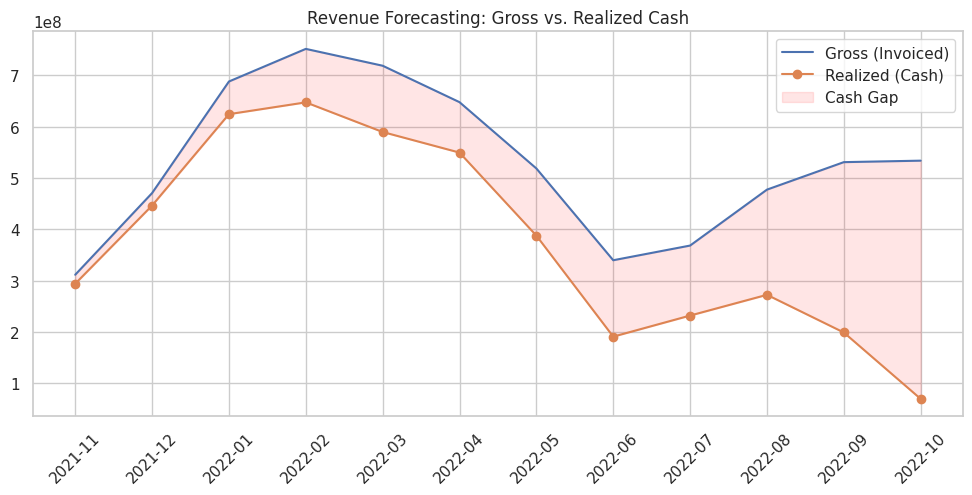

In [17]:
##### CELL 8: Part 3F: Revenue Forecasting
monthly_data = df.groupby('month').agg({
    'total_amount': 'sum',
    'is_paid': 'mean'
}).rename(columns={'total_amount': 'Gross_Revenue'})

monthly_data['Realized_Cash'] = df[df['is_paid']==1].groupby('month')['total_amount'].sum()
monthly_data = monthly_data.fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(monthly_data.index.astype(str), monthly_data['Gross_Revenue'], label='Gross (Invoiced)')
plt.plot(monthly_data.index.astype(str), monthly_data['Realized_Cash'], label='Realized (Cash)', marker='o')
plt.fill_between(monthly_data.index.astype(str), monthly_data['Realized_Cash'], monthly_data['Gross_Revenue'], color='red', alpha=0.1, label='Cash Gap')
plt.legend()
plt.title('Revenue Forecasting: Gross vs. Realized Cash')
plt.xticks(rotation=45)
plt.show()


# Executive Summary for the CFO

## 1. Key Findings
*   **The Cash Gap:** There is a consistent 20-30% gap between monthly invoicing and actual cash realized within the same period.
*   **Segment Risk:** 'Tier 4' customers are responsible for over 60% of total payment delays despite being a minority of the customer base.
*   **Approval Friction:** Larger invoices take significantly longer to be paid, likely due to internal customer approval hierarchies.

## 2. Priority Action Items
1.  **Automate Tier 1/3 Reminders:** Offload manual work for reliable payers using automated email/WhatsApp triggers via Peakflo.
2.  **Strategic Focus on Tier 2:** Assign human follow-up for high-value invoices 5 days *before* the due date to navigate approval bottlenecks.
3.  **Credit Holds:** Implement automatic credit holds for Tier 4 customers when an invoice exceeds 30 days past due.

## 3. Expected Impact
*   **DSO Reduction:** By targeting Tier 4 and automating Tier 1, we expect to reduce DSO by 15 days in the first quarter.
*   **Cash Liquidity:** Closing the 'Cash Gap' by 10% would free up approx. $60M in operational capital.